In [1]:
import gpytorch
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pyro
import torch

from distributions.Plackett_Luce import make_permutation_matrix
from generators.probabilistic_generator import Generator
from metrics import count_accuracy, get_CPDAG
from models.deep_probabilistic.MNCASTLE import CausalOrder, CausalCoeff
from pyro.infer import SVI, TraceGraph_ELBO
from pyro.optim import ClippedAdam
from tqdm.notebook import tqdm
from utils import _block_diag

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
plt.rcParams['text.usetex'] = True

# Generate synthetic data

In [4]:
T=100
N=5
multiscale=.5
nonstationarity=.5
density=.5

In [5]:
gen = Generator(N=N, T=T, multiscale=multiscale, nonstationarity=nonstationarity, density=density)
X=gen.generate()

In [6]:
print(r'Causal ordering={}; Total number of time scales J={}.'.format(gen.ordering.numpy(), gen.J.item()))

Causal ordering=[0 1 4 3 2]; Total number of time scales J=4.


# Inference

In [7]:
kernel =  gpytorch.kernels.RBFKernel(lengthscale_constraint=gpytorch.constraints.GreaterThan(1.),lengthscale_prior=None)

train_x = torch.linspace(0, 1, T).view(1,1,1,-1,1).repeat(gen.J,N,N,1,1)

In [8]:
#adapted from https://github.com/cornellius-gp/gpytorch/blob/master/examples/07_Pyro_Integration/Cox_Process_Example.ipynb

def percentiles_from_samples(samples, percentiles=[0.01, 0.5, 0.99]):
    num_samples = samples.size(0)
    samples = samples.sort(dim=0)[0]

    # Get samples corresponding to percentile
    percentile_samples = [samples[int(num_samples * percentile)] for percentile in percentiles]

    return percentile_samples

In [20]:
pyro.clear_param_store()

num_iter =100
num_particles=10

def per_param_callable(param_name):
    global num_iter
    gamma = .1  # final learning rate will be gamma * initial_lr
    lrd = gamma ** (1 / num_iter)
    
    if 'baseline' in param_name:
        return {"lr":.03, 'betas':(.95,.999)}
    elif 'gp' in param_name:
        return {"lr":.05, 'lrd':lrd}
    else:
        return {"lr": .03, 'betas':(.95,.999), 'lrd':lrd}

def Alternating2step(train_x, X, S, kernel):
    
    J, T, N,_= S.size()
    model_order = CausalOrder(T,N)
    model_coeff = CausalCoeff(J,T,N,kernel=kernel, frac_inducing=.64)
    pyro.clear_param_store()
    optimizer = ClippedAdam(per_param_callable)
    elbo = TraceGraph_ELBO(num_particles=num_particles, vectorize_particles=False, retain_graph=True)
    svi_order = SVI(model_order.model, model_order.guide, optimizer, elbo)
    svi_coeff = SVI(model_coeff.model, model_coeff.guide, optimizer, elbo)

    model_coeff.train()
    iterator = tqdm(range(num_iter))
    for i in iterator:
        model_coeff.zero_grad()
        loss_order = svi_order.step(X)
        _b = pyro.param(model_order.name_prefix+'.theta').detach().data
        _, _order = _b.sort(descending=True)
        
        #At the beginning the model assigns equal scores
        #to all nodes and this tend to break the inference of GPs.
        #Therefore, we allow the model to differentiate nodes scores 
        #for the first 100 iterations.
        if i>25:
            loss_coeff = svi_coeff.step(train_x, _order, S)
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b,
                                 loss_coeff=loss_coeff,
                                 nonstationarity=1./model_coeff.covar_module.base_kernel.lengthscale.detach().item())
        else:
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b)
        
    test_x = torch.linspace(0, 1, T).float()
    
    model_coeff.eval()
    
    with torch.no_grad():
        output = model_coeff(test_x)    
        
    Nsamples = 1000
    samples=output(torch.Size([Nsamples]))
    lower, mean, upper = percentiles_from_samples(samples)
    ac_mean=mean.transpose(1,-1).transpose(-2,-1)
    ac_upper=upper.transpose(1,-1).transpose(-2,-1)
    ac_lower=lower.transpose(1,-1).transpose(-2,-1)
    
    theta_hat, co = pyro.param(model_order.name_prefix+".theta").cpu().detach().data.sort(descending=True)
    lengthscale = model_coeff.covar_module.base_kernel.lengthscale.cpu().detach().item()
    nonstationarity = 1./lengthscale
    c0 = model_coeff.mean_module.constant.cpu().detach().data.squeeze()
    return {
        'mean_GP': c0.numpy(),
        'ac_mean':ac_mean.numpy(),
        'ac_upper':ac_upper.numpy(),
        'ac_lower':ac_lower.numpy(),
        'b':theta_hat.numpy(),
        'causal ordering':co.numpy(),
        'lengthscale':lengthscale,
        'nonstationarity':nonstationarity}

In [21]:
# %time results=Alternating2step(train_x, X, gen.S, kernel) #use custom kernel
%time results=Alternating2step(train_x, X, gen.S, None) #uses Matern5/2 as default

None


  0%|          | 0/100 [00:00<?, ?it/s]

CPU times: total: 6min 25s
Wall time: 1min 37s


# Plot results

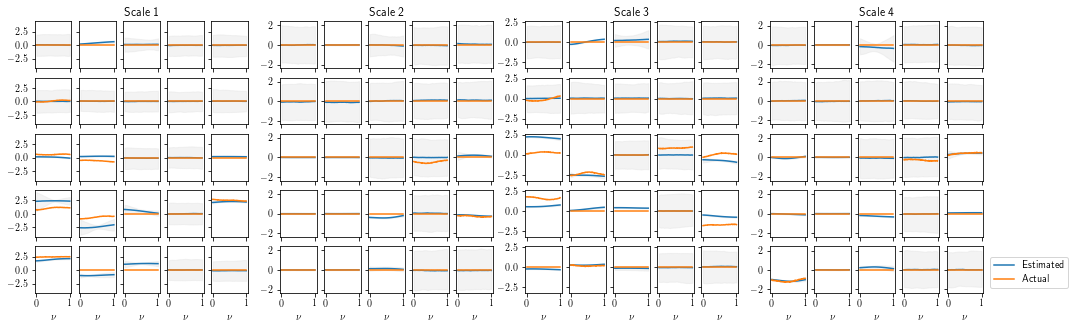

In [22]:
test_x = torch.linspace(0, 1, T).float()

fig = plt.figure(figsize=(17,5))
outer_grid = fig.add_gridspec(1, int(gen.J), wspace=0.15, hspace=0)

for scale in range(gen.J):

    inner_grid = outer_grid[scale].subgridspec(5, 5, wspace=0.2, hspace=0.2)
    title_ax = fig.add_subplot(inner_grid[:])
    title_ax.axis('off')
    title_ax.set_title('Scale {}'.format(scale+1))
    ax = inner_grid.subplots(sharey=True, sharex=True)
    
    # ax = plt.Subplot(gen.N, gen.N, figsize=(5,7), sharey=True, sharex=True)

    for i,j in itertools.product(range(gen.N), range(gen.N)):
        ax[i,j].plot(test_x, results['ac_mean'][scale,:,i,j], label='Estimated')
        ax[i,j].fill_between(
            test_x, results['ac_lower'][scale,:,i,j],
            results['ac_upper'][scale,:,i,j], color='#d9d9d9', alpha=0.3
        )

        ax[i,j].plot(test_x, gen.C[scale,-T:,i,j], label='Actual')
        # ax[i,j].axhline(0, linestyle='-', color='grey', label='No relation')
        if i==N-1: ax[i,j].set_xlabel("$\\nu$")
        # ax[i,j].axhline(-.1, linestyle='--', color='red')
        # ax[i,j].axhline(.1, linestyle='--', color='red')
ax[i,j].legend(bbox_to_anchor=[1.05, 0.], loc='lower left')

plt.show()

# Metrics

In [23]:
causal_adj = torch.zeros(results['mean_GP'].shape)
for j,n,m in itertools.product(range(causal_adj.shape[0]),range(causal_adj.shape[1]),range(causal_adj.shape[2])):
    
    hard_thresh=(np.abs(results['ac_lower'][j,:,n,m])>.1).sum() + (np.abs(results['ac_upper'][j,:,n,m])>.1).sum()
    confidence=(np.sign(results['ac_lower'][j,:,n,m]*results['ac_upper'][j,:,n,m])).sum()
    if hard_thresh>0 and confidence!=-results['ac_mean'].shape[1]: 
        causal_adj[j,n,m]+=1.

In [24]:
ordering_est = results['causal ordering']
B=torch.tril(torch.ones([N,N]), diagonal=-1)
P_=make_permutation_matrix(torch.tensor(ordering_est)).to(device)
B=P_.T@B@P_
causal_adj = B*causal_adj
print(ordering_est, gen.ordering)

[1 0 4 2 3] tensor([0, 1, 4, 3, 2])


In [25]:
td=get_CPDAG(_block_diag(torch.abs(torch.sign(gen.C[:,0])).numpy()))
est=get_CPDAG(_block_diag((B*causal_adj).numpy()))
count_accuracy(td, est)

{'fdr|(1-precision)': 0.4827586206896552,
 'tpr|recall': 0.75,
 'fpr': 0.08235294117647059,
 'f1': 0.6122448979591837,
 'shd-missing': 0,
 'shd-extra': 9,
 'shd-reverse': 5,
 'shd': 14,
 'pred-und': 0,
 'f-und': 0.0,
 'nnz': 29,
 'true_nnz': 20,
 'ae_nnz': 9}